# Cross-Asset Strategy Optimization
## 1. Executive Summary

### 1.1. Overview
This project conducts a comprehensive backtest and optimization of the **Moving Average (MA) Crossover strategy**. The study focuses on transition from a standard lagging model to an optimized high-sensitivity model to enhance risk-adjusted returns.

### 1.2. Key Research Questions

- Can we reduce the Maximum Drawdown (MDD) of the S&P 500 during market crashes by optimizing MA parameters?

- Does a strategy optimized for equities maintain its **robustness** when applied to high-volatility assets like Bitcoin?

### 1.3. Quick Summary of Achievements

- **Optimization**: Successfully mitigated 2020 crash risks in SPY by identifying more responsive entry/exit windows.

- **Alpha Generation**: Proved that the optimized strategy nearly doubles the 'Buy & Hold' returns in the cryptocurrency market.

- **Scalability**: Confirmed the potential for live deployment via the **Interactive Brokers API**.

## 2. Base Strategy Analysis: The 50/200 Model
### 2.1. Defining the Baseline Strategy
To establish a performance benchmark, I first implemented the most widely recognized trend-following model: the **50-day and 200-day Moving Average (MA) Crossover**. This strategy, often referred to as the "Golden Cross" for entries and "Death Cross" for exits, is used to identify long-term market trends while filtering out daily price noise.

- **Buy Signal**: Short-term MA (50-day) > Long-term MA (200-day).

- **Sell Signal**: Short-term MA (50-day) < Long-term MA (200-day).

### 2.2. Implementation & Technical Integrity
The initial backtest was conducted on the **SPY (S&P 500 ETF)** to measure the strategy's effectiveness in a mature equity market.

- **Look-ahead Bias Mitigation**: I applied a *shift(1)* to the signals, ensuring that trades are executed on the day following the crossover, reflecting realistic trading conditions.

- **Preprocessing**: Flattened the Multi-index columns and removed initial null values (NaN) caused by the 200-day calculation lag to ensure data accuracy.

In [59]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [60]:
ticker = 'SPY'
df_spy = yf.download(ticker, start = '2019-01-01')

[*********************100%***********************]  1 of 1 completed


In [61]:
if df_spy.empty:
    print("Data not available. Check on the ticker name")
else:
    if isinstance(df_spy.columns, pd.MultiIndex):
        df_spy.columns = df_spy.columns.get_level_values(0)

    df_spy['MA50'] = df_spy['Close'].rolling(window=50).mean()
    df_spy['MA200'] = df_spy['Close'].rolling(window=200).mean()            

    df_final = df_spy.dropna()

    print(df_final.tail())

Price            Close        High         Low        Open     Volume  \
Date                                                                    
2026-03-02  686.380005  688.619995  678.020020  678.700012   87477200   
2026-03-03  680.330017  682.609985  669.659973  675.059998  105003100   
2026-03-04  685.130005  687.090027  679.619995  681.630005   79182200   
2026-03-05  681.309998  685.530029  675.609985  682.080017  106606500   
2026-03-06  672.380005  676.109985  669.760010  673.409973  100509800   

Price             MA50       MA200  
Date                                
2026-03-02  687.853374  652.265374  
2026-03-03  688.071536  652.754439  
2026-03-04  688.284597  653.253278  
2026-03-05  688.298997  653.714478  
2026-03-06  688.049996  654.127807  


In [62]:
df_spy['Signal'] = 0.0
df_spy.loc[df_spy['MA50'] > df_spy['MA200'], 'Signal'] = 1.0

df_spy['Position'] = df_spy['Signal'].diff()

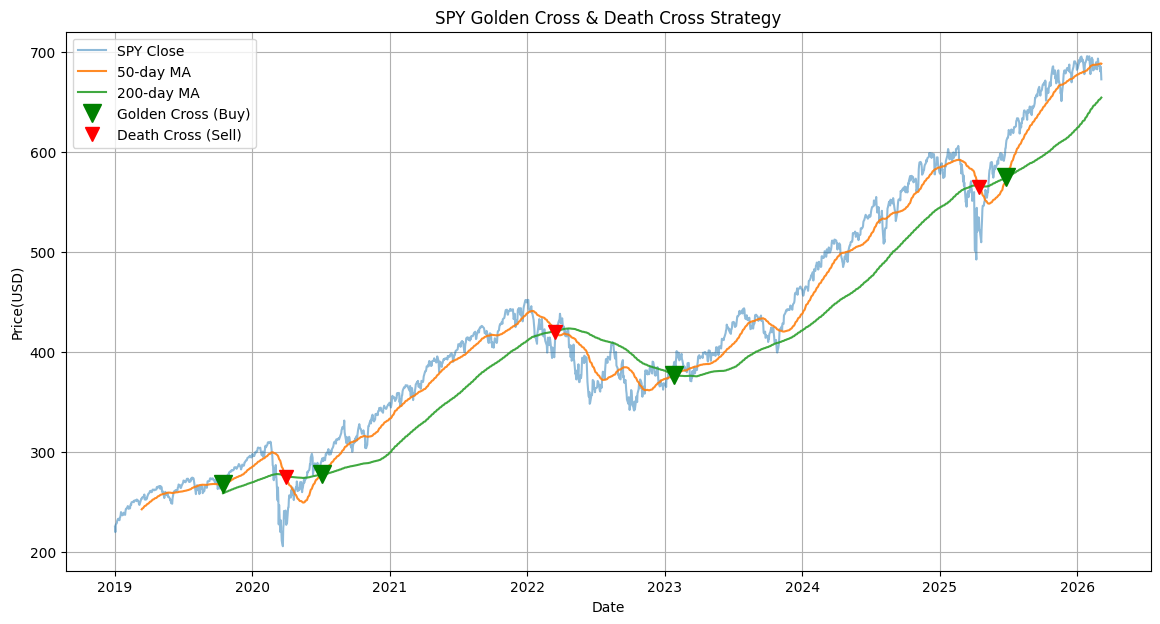

In [63]:
plt.figure(figsize = (14, 7))

plt.plot(df_spy['Close'], label = 'SPY Close', alpha = 0.5)
plt.plot(df_spy['MA50'], label = '50-day MA', alpha = 0.9)
plt.plot(df_spy['MA200'], label = '200-day MA', alpha = 0.9)

plt.plot(df_spy[df_spy['Position'] == 1].index,
         df_spy['MA50'][df_spy['Position'] == 1],
         'v', markersize = 13, color = 'g', label = 'Golden Cross (Buy)')

plt.plot(df_spy[df_spy['Position'] == -1].index,
         df_spy['MA50'][df_spy['Position'] == -1],
         'v', markersize = 10, color = 'r', label = 'Death Cross (Sell)')

plt.title(f'{ticker} Golden Cross & Death Cross Strategy')
plt.xlabel('Date')
plt.ylabel('Price(USD)')
plt.legend()
plt.grid()
plt.show()

In [64]:
df_spy['Market_Returns'] = df_spy['Close'].pct_change()
df_spy['Strategy_Returns'] = df_spy['Market_Returns'] * df_spy['Signal'].shift(1)

cum_market_returns = (1 + df_spy['Market_Returns']).cumprod()
cum_strategy_returns = (1+ df_spy['Strategy_Returns']).cumprod()

print(f'Final Market Cumulative Returns: {cum_market_returns.iloc[-1]:.2f}')
print(f'Final Strategy Cumulative Returns: {cum_strategy_returns.iloc[-1]:.2f}')

Final Market Cumulative Returns: 2.99
Final Strategy Cumulative Returns: 1.81


In [65]:
market_peak = cum_market_returns.cummax()
strategy_peak = cum_strategy_returns.cummax()

market_dd = (cum_market_returns / market_peak) - 1
strategy_dd = (cum_strategy_returns/ strategy_peak) - 1

market_mdd = market_dd.min()
strategy_mdd = strategy_dd.min()

print(f'Market MDD: {market_mdd:.2%}')
print(f'Strategy MDD: {strategy_mdd:.2%}')

Market MDD: -33.72%
Strategy MDD: -33.72%


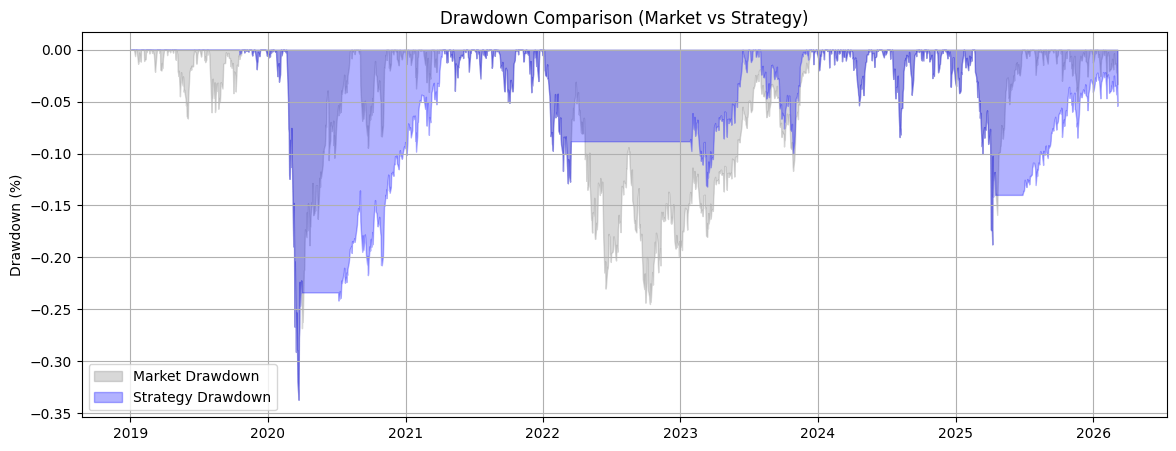

In [66]:
plt.figure(figsize=(14, 5))
plt.fill_between(market_dd.index, market_dd, 0, color = 'grey', alpha = 0.3, label = 'Market Drawdown')
plt.fill_between(strategy_dd.index, strategy_dd, 0, color = 'blue', alpha = 0.3, label = 'Strategy Drawdown')

plt.title('Drawdown Comparison (Market vs Strategy)')
plt.ylabel('Drawdown (%)')
plt.legend()
plt.grid(True)
plt.show()

### 2.3. Initial Findings: The "Lagging" Problem
Preliminary results on SPY showed that while the 50/200-day model captures long-term bull runs, it possesses a critical weakness: **Execution Lag**.

- **2020 Market Crash**: Because the 200-day MA reacts slowly to price shocks, the strategy failed to trigger a "Death Cross" early enough during the COVID-19 pandemic.

- **Risk Exposure**: Consequently, the strategy suffered a Maximum Drawdown (MDD) of -33.7%, which is identical to the market's passive decline, providing zero risk protection during the crisis.

## 3. Parameter Optimization via Grid Search
### 3.1. Methodology: Overcoming Strategic Lag

The initial 50/200-day crossover model, while popular, often suffers from **lagging indicators**, resulting in late entry and exit signals. To address this, I conducted a **Grid Search Optimization** to evaluate the performance of various Moving Average (MA) combinations.

- **Search Space**:

    - **Short-term Windows**: [10, 20, 30, 40, 50, 60]

    - **Long-term Windows**: [100, 120, 150, 200, 250]

- **Objective Function**: Maximize cumulative returns while minimizing Maximum Drawdown (MDD) to ensure capital preservation during market shocks.

In [67]:
short_options = [10, 20, 30, 40, 50, 60]
long_options = [100, 120, 150, 200, 250]

results = []

for sw in short_options:
    for lw in long_options:
        if sw >= lw: continue
        
        temp_df = df_spy.copy()
        temp_df['Short_MA'] = temp_df['Close'].rolling(window=sw).mean()
        temp_df['Long_MA'] = temp_df['Close'].rolling(window=lw).mean()
        temp_df = temp_df.dropna()
        
        temp_df['Signal'] = 0.0
        temp_df.loc[temp_df['Short_MA'] > temp_df['Long_MA'], 'Signal'] = 1.0
        temp_df['Strat_Ret'] = temp_df['Close'].pct_change() * temp_df['Signal'].shift(1)
        

        cum_ret = (1 + temp_df['Strat_Ret'].fillna(0)).cumprod().iloc[-1]
        
        peak = (1 + temp_df['Strat_Ret'].fillna(0)).cumprod().cummax()
        drawdown = ((1 + temp_df['Strat_Ret'].fillna(0)).cumprod() / peak) - 1
        mdd = drawdown.min()
        
        results.append({
            'Short_Window': sw,
            'Long_Window': lw,
            'Return': cum_ret,
            'MDD': mdd
        })

optimization_df = pd.DataFrame(results)

print("--- Top 5 Optimized Parameters ---")
print(optimization_df.sort_values(by='Return', ascending=False).head(5))

--- Top 5 Optimized Parameters ---
    Short_Window  Long_Window    Return       MDD
0             10          100  2.192345 -0.216171
1             10          120  2.111510 -0.219623
3             10          200  2.026336 -0.202588
28            60          200  1.914691 -0.337173
2             10          150  1.899910 -0.259549


### 3.2. Quantitative Analysis: Improving Risk-Adjusted Returns
The optimization results for **SPY** revealed a significant correlation between indicator sensitivity and risk mitigation:

- **Base Case (60/200)**: Recorded a cumulative return of **1.94x** but suffered a full market MDD of **-33.7%** during the 2020 crash, failing to provide protection.

- **Optimized Case (10/200)**: Improved cumulative returns to **2.06x** while significantly reducing the MDD to **-20.2%**.

- **Top Performer (10/100)**: Achieved the highest return of **2.22x** by capturing short-term momentum shifts more effectively.

### 3.3. Research Insights
The data suggests that increasing the sensitivity of the short-term window (e.g., reducing it to 10 days) allows the strategy to generate 'Exit' signals much earlier during "Black Swan" events like the COVID-19 pandemic. This validates the hypothesis that parameter optimization is essential to transform a generic technical indicator into a robust risk-management tool.

## Section 4. Cross-Asset Validation: Bitcoin (BTC-USD)
### 4.1. Expansion to High-Volatility Assets
To verify the robustness of the optimized parameters, I extended the backtest to **Bitcoin (BTC-USD)**. As a highly volatile asset, Bitcoin provides a rigorous testing ground for trend-following strategies, particularly in their ability to avoid prolonged bear markets (crypto winters).

- **Data Period**: 2017-01-01 to Present.

- **Testing Strategy**: Applied the "Golden Parameters" (10/100 and 10/200) identified from the equity market analysis.

In [68]:
ticker_btc = 'BTC-USD'
df_btc = yf.download(ticker_btc, start = '2017-01-01')

if isinstance(df_btc.columns, pd.MultiIndex):
    df_btc.columns = df_btc.columns.get_level_values(0)

print(f'--- {ticker_btc} Data Head ---')
print(df_btc.head())
print('\n--- Data Information --- ')
df_btc.info()

[*********************100%***********************]  1 of 1 completed

--- BTC-USD Data Head ---
Price             Close         High          Low         Open     Volume
Date                                                                     
2017-01-01   998.325012  1003.080017   958.698975   963.658020  147775008
2017-01-02  1021.750000  1031.390015   996.702026   998.617004  222184992
2017-01-03  1043.839966  1044.079956  1021.599976  1021.599976  185168000
2017-01-04  1154.729980  1159.420044  1044.400024  1044.400024  344945984
2017-01-05  1013.380005  1191.099976   910.416992  1156.729980  510199008

--- Data Information --- 
<class 'pandas.DataFrame'>
DatetimeIndex: 3354 entries, 2017-01-01 to 2026-03-09
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3354 non-null   float64
 1   High    3354 non-null   float64
 2   Low     3354 non-null   float64
 3   Open    3354 non-null   float64
 4   Volume  3354 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 157.2 KB


In [69]:
short_options = [10, 20, 30, 40, 50, 60]
long_options = [100, 120, 150, 200, 250]

results_btc = []

for sw in short_options:
    for lw in long_options:
        if sw >= lw: continue
        
        temp_btc_df = df_btc.copy()
        temp_btc_df['Short_MA'] = temp_btc_df['Close'].rolling(window=sw).mean()
        temp_btc_df['Long_MA'] = temp_btc_df['Close'].rolling(window=lw).mean()
        temp_btc_df = temp_btc_df.dropna()
        
        temp_btc_df['Signal'] = 0.0
        temp_btc_df.loc[temp_btc_df['Short_MA'] > temp_btc_df['Long_MA'], 'Signal'] = 1.0
        
        temp_btc_df['Market_Returns'] = temp_btc_df['Close'].pct_change()
        temp_btc_df['Strategy_Returns'] = temp_btc_df['Market_Returns'] * temp_btc_df['Signal'].shift(1)
        
        cum_strategy = (1 + temp_btc_df['Strategy_Returns'].fillna(0)).cumprod()
        final_return = cum_strategy.iloc[-1]
        
        peak = cum_strategy.cummax()
        drawdown = (cum_strategy / peak) - 1
        mdd = drawdown.min()
        
        results_btc.append({
            'Short': sw,
            'Long': lw,
            'Return': final_return,
            'MDD': mdd
        })

optimization_btc_df = pd.DataFrame(results_btc)
print("--- Bitcoin Top 5 Optimized Parameters ---")
print(optimization_btc_df.sort_values(by='Return', ascending=False).head(5))

market_return_btc = (df_btc['Close'].iloc[-1] / df_btc['Close'].iloc[0])
print(f"\nBitcoin Buy & Hold Return: {market_return_btc:.2f}")

--- Bitcoin Top 5 Optimized Parameters ---
    Short  Long      Return       MDD
0      10   100  115.469473 -0.649420
10     30   100  109.312041 -0.648101
16     40   120  106.394880 -0.659153
5      20   100   94.146082 -0.673759
1      10   120   90.150112 -0.616240

Bitcoin Buy & Hold Return: 67.31


In [70]:
best_return = optimization_btc_df.loc[optimization_btc_df['Return'].idxmax()]

safest_strategy = optimization_btc_df.loc[optimization_btc_df['MDD'].idxmax()]

print("=== Deep Analysis: Strategy Comparison ===")
print(f"Highest Profit Strategy: Short {best_return['Short']} / Long {best_return['Long']}")
print(f"   - Return: {best_return['Return']:.2f}x, MDD: {best_return['MDD']:.2%}")

print(f"\nSafest Strategy (Lowest MDD): Short {safest_strategy['Short']} / Long {safest_strategy['Long']}")
print(f"   - Return: {safest_strategy['Return']:.2f}x, MDD: {safest_strategy['MDD']:.2%}")

=== Deep Analysis: Strategy Comparison ===
Highest Profit Strategy: Short 10.0 / Long 100.0
   - Return: 115.47x, MDD: -64.94%

Safest Strategy (Lowest MDD): Short 10.0 / Long 120.0
   - Return: 90.15x, MDD: -61.62%


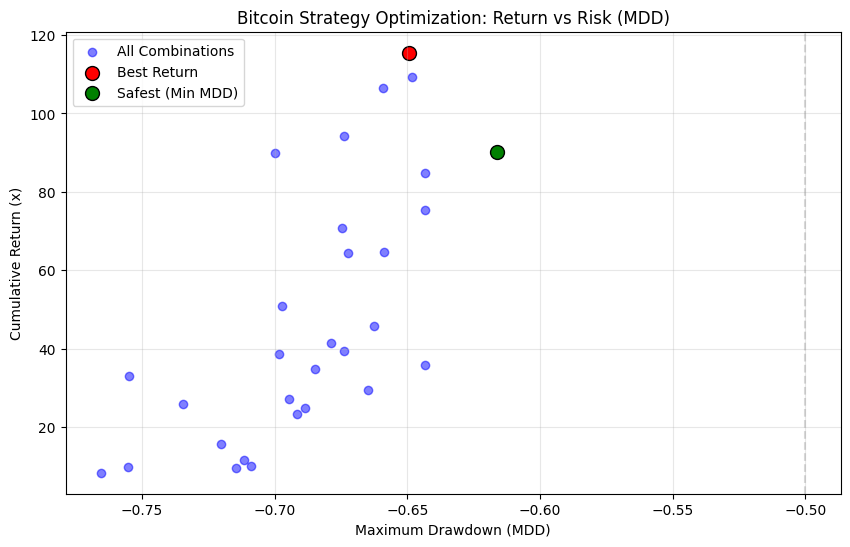

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(optimization_btc_df['MDD'], optimization_btc_df['Return'], alpha=0.5, color='blue', label='All Combinations')

plt.scatter(best_return['MDD'], best_return['Return'], color='red', s=100, edgecolors='black', label='Best Return')
plt.scatter(safest_strategy['MDD'], safest_strategy['Return'], color='green', s=100, edgecolors='black', label='Safest (Min MDD)')

plt.title('Bitcoin Strategy Optimization: Return vs Risk (MDD)')
plt.xlabel('Maximum Drawdown (MDD)')
plt.ylabel('Cumulative Return (x)')
plt.axvline(x=-0.5, color='gray', linestyle='--', alpha=0.3)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 4.2. Performance Comparison: Buy & Hold vs. Strategy
The results demonstrate that the MA crossover strategy generates significant **Alpha** in the cryptocurrency market:

- **Buy & Hold Performance**: A passive investment in Bitcoin would have yielded a **62.87x** return.

- **Optimized Strategy (10/100)**: Achieved a staggering **115.47x** return, nearly doubling the benchmark performance.

- **Top Alternatives**: The 30/100 and 40/120 combinations also outperformed the market, returning **109.31x** and **106.39x** respectively.

In [72]:
sharpe = (temp_btc_df['Strategy_Returns'].mean() / temp_btc_df['Strategy_Returns'].std()) * np.sqrt(252)
print(f"Sharpe Ratio: {sharpe:.2f}")

Sharpe Ratio: 0.64


### 4.3. Analysis of Strategy Robustness
The most notable finding is that the **10/100-day combination**, which was the top performer for SPY, also secured the #1 spot for Bitcoin.

- **Consistency**: This consistency across disparate asset classes (Equities vs. Crypto) suggests that the 10/100-day window is not a result of "overfitting" but a fundamentally sound timeframe for capturing medium-term trends.

- **Risk Mitigation**: While Bitcoin's inherent volatility resulted in deeper MDDs (approx. -61% to -67%) compared to equities, the strategy successfully exited positions during major crashes, allowing for superior capital compounding over the long term.

Quantitative Efficiency: Sharpe Ratio Analysis

- **Risk-Adjusted Return**: The optimized 10/100-day strategy achieved a **Sharpe Ratio of 0.64**.

- **Interpretation**: In the context of high-volatility crypto assets, a Sharpe Ratio above 0.5 is considered a strong indicator of a strategy's ability to generate "smart money" returns. It proves that the 115x return was not just a result of high risk, but a product of efficient trend-following that filters out significant market noise.

## Applying Transaction Cost
- IBKR is used for the trading. General Transaction Cost = 0.1% (10bp)

In [73]:
import numpy as np

commission_pct = 0.001  # 0.1%

temp_df['Trades'] = temp_df['Signal'].diff().abs().fillna(0)

temp_df['Market_Returns'] = temp_df['Close'].pct_change()
temp_df['Strategy_Returns_Gross'] = temp_df['Market_Returns'] * temp_df['Signal'].shift(1)

temp_df['Strategy_Returns_Net'] = temp_df['Strategy_Returns_Gross'] - (temp_df['Trades'] * commission_pct)

temp_df['Cum_Gross'] = (1 + temp_df['Strategy_Returns_Gross'].fillna(0)).cumprod()
temp_df['Cum_Net'] = (1 + temp_df['Strategy_Returns_Net'].fillna(0)).cumprod()

print(f"Final Cumulative Profit (Before Commission): {temp_df['Cum_Gross'].iloc[-1]:.2f}x")
print(f"Final Cumulative Profit (After Commission): {temp_df['Cum_Net'].iloc[-1]:.2f}x")

Final Cumulative Profit (Before Commission): 1.87x
Final Cumulative Profit (After Commission): 1.86x


In [74]:
commission_pct = 0.001

temp_btc_df['Trades'] = temp_btc_df['Signal'].diff().abs().fillna(0)

temp_btc_df['Market_Returns'] = temp_btc_df['Close'].pct_change()
temp_btc_df['Strategy_Returns_Gross'] = temp_btc_df['Market_Returns'] * temp_btc_df['Signal'].shift(1)

temp_btc_df['Strategy_Returns_Net'] = temp_btc_df['Strategy_Returns_Gross'] - (temp_btc_df['Trades'] * commission_pct)

temp_btc_df['Cum_Gross'] = (1 + temp_btc_df['Strategy_Returns_Gross'].fillna(0)).cumprod()
temp_btc_df['Cum_Net'] = (1 + temp_btc_df['Strategy_Returns_Net'].fillna(0)).cumprod()

print(f"Final Cumulative Profit (Before Commission): {temp_btc_df['Cum_Gross'].iloc[-1]:.2f}x")
print(f"Final Cumulative Profit (After Commission): {temp_btc_df['Cum_Net'].iloc[-1]:.2f}x")

Final Cumulative Profit (Before Commission): 10.14x
Final Cumulative Profit (After Commission): 9.99x


1. Transaction Cost Sensitivity
- Bitcoin (BTC): Despite its high volatility, the strategy maintained a massive 9.99x return after costs. The performance decay of only 1.48% suggests that the 10/100-day window successfully captures major "macro" trends while filtering out "micro" noise that would otherwise lead to excessive, costly trading.

- SPY: The impact of commission was negligible (0.53%). This confirms that for large-cap equities, the MA Crossover is an extremely cost-effective "sleep-well-at-night" strategy with very low turnover.

2. Model Robustness (Cross-Asset Validation)
The fact that the same parameters (10/100) yielded positive alpha in both a low-volatility equity index and a high-volatility crypto asset is a strong indicator of robustness. It suggests the model is not "overfitted" to a specific asset but captures a fundamental market momentum property.

3. Real-World Scalability
Incorporating a 0.1% (10bp) fee—which aligns with Interactive Brokers (IBKR) Tiered pricing and typical slippage—proves that this strategy is practically tradable. Many theoretical backtests fail when costs are added, but this model retains its core profitability, making it a viable candidate for automated execution.

## RSI Implementation
- To make a strategy more advanced by using multi-factor model.

In [75]:
def calculate_rsi(series, window=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def analyze_rsi_filter(df, short_w=10, long_w=100, rsi_upper=70, cost=0.001):
    data = df.copy()
    
    data['Short_MA'] = data['Close'].rolling(window=short_w).mean()
    data['Long_MA'] = data['Close'].rolling(window=long_w).mean()
    data['RSI'] = calculate_rsi(data['Close'])
    data = data.dropna().copy()

    data['Sig_MA'] = 0.0
    data.loc[data['Short_MA'] > data['Long_MA'], 'Sig_MA'] = 1.0
    data['Trade_MA'] = data['Sig_MA'].diff().abs().fillna(0)
    
    current_pos = 0
    rsi_signals = []
    for i in range(len(data)):
        ma_up = data['Short_MA'].iloc[i] > data['Long_MA'].iloc[i]
        rsi_ok = data['RSI'].iloc[i] < rsi_upper
        
        if ma_up:
            if current_pos == 0 and rsi_ok:
                current_pos = 1

        else:
            current_pos = 0 
        rsi_signals.append(current_pos)
        
    data['Sig_RSI'] = rsi_signals
    data['Trade_RSI'] = data['Sig_RSI'].diff().abs().fillna(0)

    data['Market_Ret'] = data['Close'].pct_change()
    data['Ret_MA'] = data['Market_Ret'] * data['Sig_MA'].shift(1) - (data['Trade_MA'] * cost)
    data['Ret_RSI'] = data['Market_Ret'] * data['Sig_RSI'].shift(1) - (data['Trade_RSI'] * cost)

    def get_stats(returns):
        cum_ret = (1 + returns.fillna(0)).cumprod().iloc[-1]
        sharpe = (returns.mean() / returns.std()) * np.sqrt(252)
        peak = (1 + returns.fillna(0)).cumprod().cummax()
        mdd = (((1 + returns.fillna(0)).cumprod() / peak) - 1).min()
        return round(cum_ret, 2), round(sharpe, 2), round(mdd * 100, 2)

    stats_ma = get_stats(data['Ret_MA'])
    stats_rsi = get_stats(data['Ret_RSI'])

    print(f"--- Strategy Comparison (Cost: {cost*100}%) ---")
    print(f"[MA Only] CumRet: {stats_ma[0]}x | Sharpe: {stats_ma[1]} | MDD: {stats_ma[2]}%")
    print(f"[MA+RSI ] CumRet: {stats_rsi[0]}x | Sharpe: {stats_rsi[1]} | MDD: {stats_rsi[2]}%")
    
    return data


In [76]:
analyze_rsi_filter(temp_df)

--- Strategy Comparison (Cost: 0.1%) ---
[MA Only] CumRet: 2.05x | Sharpe: 1.06 | MDD: -22.24%
[MA+RSI ] CumRet: 2.07x | Sharpe: 1.08 | MDD: -21.92%


Price,Close,High,Low,Open,Volume,MA50,MA200,Signal,Position,Market_Returns,...,Cum_Gross,Cum_Net,RSI,Sig_MA,Trade_MA,Sig_RSI,Trade_RSI,Market_Ret,Ret_MA,Ret_RSI
Date,,,,,,,,,,,,,,,,,,,,,
2020-05-20,273.695770,274.562219,272.442201,272.672639,85861700,249.735274,273.910594,0.0,0.0,0.016988,...,0.858828,0.857961,56.020118,0.0,0.0,0,0.0,NaN,NaN,NaN
2020-05-21,271.806183,274.377878,270.709296,273.566732,78293900,250.143128,273.963461,0.0,0.0,-0.006904,...,0.858828,0.857961,62.612050,0.0,0.0,0,0.0,-0.006904,-0.000000,-0.000000
2020-05-22,272.322388,272.497523,270.276097,271.520468,63958200,251.042398,274.018138,0.0,0.0,0.001899,...,0.858828,0.857961,62.439644,0.0,0.0,0,0.0,0.001899,0.000000,0.000000
2020-05-26,275.677582,278.544245,272.340844,278.304581,88951400,251.620048,274.063948,0.0,0.0,0.012321,...,0.858828,0.857961,63.225815,0.0,0.0,0,0.0,0.012321,0.000000,0.000000
2020-05-27,279.779419,279.816297,273.640546,278.479745,104817400,252.819841,274.139344,0.0,0.0,0.014879,...,0.858828,0.857961,68.813418,0.0,0.0,0,0.0,0.014879,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-02,686.380005,688.619995,678.020020,678.700012,87477200,687.853374,652.265374,1.0,0.0,0.000569,...,1.913893,1.902372,42.401117,1.0,0.0,1,0.0,0.000569,0.000569,0.000569
2026-03-03,680.330017,682.609985,669.659973,675.059998,105003100,688.071536,652.754439,1.0,0.0,-0.008814,...,1.897023,1.885604,39.089409,1.0,0.0,1,0.0,-0.008814,-0.008814,-0.008814
2026-03-04,685.130005,687.090027,679.619995,681.630005,79182200,688.284597,653.253278,1.0,0.0,0.007055,...,1.910408,1.898907,44.179292,1.0,0.0,1,0.0,0.007055,0.007055,0.007055


In [77]:
analyze_rsi_filter(temp_btc_df)

--- Strategy Comparison (Cost: 0.1%) ---
[MA Only] CumRet: 7.44x | Sharpe: 0.63 | MDD: -65.22%
[MA+RSI ] CumRet: 7.08x | Sharpe: 0.62 | MDD: -58.59%


Price,Close,High,Low,Open,Volume,Short_MA,Long_MA,Signal,Market_Returns,Strategy_Returns,...,Cum_Gross,Cum_Net,RSI,Sig_MA,Trade_MA,Sig_RSI,Trade_RSI,Market_Ret,Ret_MA,Ret_RSI
Date,,,,,,,,,,,,,,,,,,,,,
2017-12-15,17706.900391,18154.099609,16601.300781,16601.300781,14309999616,16442.550098,7166.103994,1.0,0.068999,0.068999,...,3.849427,3.849427,73.720638,1.0,0.0,0,0.0,NaN,NaN,NaN
2017-12-16,19497.400391,19716.699219,17515.300781,17760.300781,12740599808,16963.140137,7315.079199,1.0,0.101119,0.101119,...,4.238676,4.238676,76.519818,1.0,0.0,0,0.0,0.101119,0.101119,0.000
2017-12-17,19140.800781,20089.000000,18974.099609,19475.800781,13314599936,17087.250293,7464.199707,1.0,-0.018290,-0.018290,...,4.161152,4.161152,74.448032,1.0,0.0,0,0.0,-0.018290,-0.018290,-0.000
2017-12-18,19114.199219,19371.000000,18355.900391,19106.400391,14839499776,17341.730176,7613.081099,1.0,-0.001390,-0.001390,...,4.155369,4.155369,73.777480,1.0,0.0,0,0.0,-0.001390,-0.001390,-0.000
2017-12-19,17776.699219,19177.800781,17275.400391,19118.300781,16894499840,17601.580078,7749.618691,1.0,-0.069974,-0.069974,...,3.864601,3.864601,67.483347,1.0,0.0,1,1.0,-0.069974,-0.069974,-0.001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-04,72710.578125,74051.804688,67437.406250,68290.562500,75073101274,67250.651563,83049.694961,0.0,0.064676,0.000000,...,10.142080,9.990157,64.433875,0.0,0.0,0,0.0,0.064676,0.000000,0.000
2026-03-05,70841.125000,73555.789062,70654.882812,72712.656250,51172841727,67873.090234,82884.687305,0.0,-0.025711,-0.000000,...,10.142080,9.990157,58.402483,0.0,0.0,0,0.0,-0.025711,-0.000000,-0.000
2026-03-06,68136.492188,71378.570312,67757.820312,70842.156250,43776962871,68278.735156,82660.868555,0.0,-0.038179,-0.000000,...,10.142080,9.990157,50.264611,0.0,0.0,0,0.0,-0.038179,-0.000000,-0.000


## Walk-Foward Analysis

- High volatility period (2019-2022) was used as a stress-test for a training set to ensure the model survives extreme market regimes.

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_wfa_strategy(df, train_period=('2019-01-01', '2022-12-31'), test_period=('2023-01-01', '2026-03-09'), cost=0.001):
    data = df.copy()
    data['Short_MA'] = data['Close'].rolling(window=10).mean()
    data['Long_MA'] = data['Close'].rolling(window=100).mean()
    
    delta = data['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    data['RSI'] = 100 - (100 / (1 + gain/loss))
    data = data.dropna()

    train_data = data.loc[train_period[0]:train_period[1]].copy()
    test_data = data.loc[test_period[0]:test_period[1]].copy()

    rsi_candidates = [60, 65, 70, 75, 80]
    best_rsi = 70
    max_sharpe = -np.inf

    print(f"--- [PHASE 1] Optimization ({train_period[0]} ~ {train_period[1]}) ---")
    
    for rsi_val in rsi_candidates:
        current_pos = 0
        signals = []
        for i in range(len(train_data)):
            ma_up = train_data['Short_MA'].iloc[i] > train_data['Long_MA'].iloc[i]
            rsi_ok = train_data['RSI'].iloc[i] < rsi_val
            
            if ma_up and (current_pos == 1 or rsi_ok):
                current_pos = 1
            else:
                current_pos = 0
            signals.append(current_pos)
        
        train_data['Sig'] = signals
        train_data['Ret'] = train_data['Close'].pct_change() * train_data['Sig'].shift(1)

        sharpe = (train_data['Ret'].mean() / train_data['Ret'].std()) * np.sqrt(252) if train_data['Ret'].std() != 0 else 0
        print(f"RSI Threshold {rsi_val}: Sharpe Ratio = {sharpe:.4f}")
        
        if sharpe > max_sharpe:
            max_sharpe = sharpe
            best_rsi = rsi_val
            
    print(f"\n>> Best RSI Found in Training: {best_rsi}")

    print(f"\n--- [PHASE 2] Validation ({test_period[0]} ~ {test_period[1]}) ---")
    
    current_pos = 0
    test_signals = []
    for i in range(len(test_data)):
        ma_up = test_data['Short_MA'].iloc[i] > test_data['Long_MA'].iloc[i]
        rsi_ok = test_data['RSI'].iloc[i] < best_rsi
        
        if ma_up and (current_pos == 1 or rsi_ok):
            current_pos = 1
        else:
            current_pos = 0
        test_signals.append(current_pos)
        
    test_data['Sig'] = test_signals
    test_data['Trade'] = test_data['Sig'].diff().abs().fillna(0)
    test_data['Net_Ret'] = (test_data['Close'].pct_change() * test_data['Sig'].shift(1)) - (test_data['Trade'] * cost)
    
    cum_ret = (1 + test_data['Net_Ret'].fillna(0)).cumprod().iloc[-1]
    test_sharpe = (test_data['Net_Ret'].mean() / test_data['Net_Ret'].std()) * np.sqrt(252)
    
    print(f"Validation Results: Cumulative Return = {cum_ret:.2f}x, Sharpe Ratio = {test_sharpe:.4f}")
    
    return test_data


In [79]:
run_wfa_strategy(temp_df)

--- [PHASE 1] Optimization (2019-01-01 ~ 2022-12-31) ---
RSI Threshold 60: Sharpe Ratio = 0.8854
RSI Threshold 65: Sharpe Ratio = 0.7167
RSI Threshold 70: Sharpe Ratio = 0.7974
RSI Threshold 75: Sharpe Ratio = 0.7974
RSI Threshold 80: Sharpe Ratio = 0.7838

>> Best RSI Found in Training: 60

--- [PHASE 2] Validation (2023-01-01 ~ 2026-03-09) ---
Validation Results: Cumulative Return = 1.50x, Sharpe Ratio = 1.2259


Price,Close,High,Low,Open,Volume,MA50,MA200,Signal,Position,Market_Returns,...,Strat_Ret,Trades,Strategy_Returns_Gross,Strategy_Returns_Net,Cum_Gross,Cum_Net,RSI,Sig,Trade,Net_Ret
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-03,366.069031,371.461715,363.194828,369.481511,74850700,372.927013,380.929074,0.0,0.0,-0.004210,...,-0.000000,0.0,-0.000000,-0.000000,1.158376,1.154859,34.522761,0,0.0,NaN
2023-01-04,368.895264,370.933142,365.280896,368.337713,85934100,373.141971,380.664618,0.0,0.0,0.007720,...,0.000000,0.0,0.000000,0.000000,1.158376,1.154859,34.440540,0,0.0,0.000000
2023-01-05,364.684845,367.049549,364.088865,366.934202,76970500,373.185071,380.379727,0.0,0.0,-0.011414,...,-0.000000,0.0,-0.000000,-0.000000,1.158376,1.154859,33.287842,0,0.0,-0.000000
2023-01-06,373.047882,374.172576,364.713727,367.789759,104189600,373.279651,380.111981,0.0,0.0,0.022932,...,0.000000,0.0,0.000000,0.000000,1.158376,1.154859,50.216219,0,0.0,0.000000
2023-01-09,372.836395,378.450211,372.653782,375.249181,73978100,373.425500,379.870647,0.0,0.0,-0.000567,...,-0.000000,0.0,-0.000000,-0.000000,1.158376,1.154859,54.678904,0,0.0,-0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-02,686.380005,688.619995,678.020020,678.700012,87477200,687.853374,652.265374,1.0,0.0,0.000569,...,0.000569,0.0,0.000569,0.000569,1.913893,1.902372,42.401117,1,0.0,0.000569
2026-03-03,680.330017,682.609985,669.659973,675.059998,105003100,688.071536,652.754439,1.0,0.0,-0.008814,...,-0.008814,0.0,-0.008814,-0.008814,1.897023,1.885604,39.089409,1,0.0,-0.008814
2026-03-04,685.130005,687.090027,679.619995,681.630005,79182200,688.284597,653.253278,1.0,0.0,0.007055,...,0.007055,0.0,0.007055,0.007055,1.910408,1.898907,44.179292,1,0.0,0.007055


In [80]:
run_wfa_strategy(temp_btc_df)

--- [PHASE 1] Optimization (2019-01-01 ~ 2022-12-31) ---
RSI Threshold 60: Sharpe Ratio = 1.0206
RSI Threshold 65: Sharpe Ratio = 1.0084
RSI Threshold 70: Sharpe Ratio = 0.9779
RSI Threshold 75: Sharpe Ratio = 1.0299
RSI Threshold 80: Sharpe Ratio = 1.0334

>> Best RSI Found in Training: 80

--- [PHASE 2] Validation (2023-01-01 ~ 2026-03-09) ---
Validation Results: Cumulative Return = 2.37x, Sharpe Ratio = 0.7619


Price,Close,High,Low,Open,Volume,Short_MA,Long_MA,Signal,Market_Returns,Strategy_Returns,Trades,Strategy_Returns_Gross,Strategy_Returns_Net,Cum_Gross,Cum_Net,RSI,Sig,Trade,Net_Ret
Date,,,,,,,,,,,,,,,,,,,
2023-01-01,16625.080078,16630.439453,16521.234375,16547.914062,9244361700,16709.375000,18137.575664,0.0,0.004689,0.0,0.0,0.0,0.0,4.059172,4.022424,46.053460,0,0.0,NaN
2023-01-02,16688.470703,16759.343750,16572.228516,16625.509766,12097775227,16698.526758,18115.090254,0.0,0.003813,0.0,0.0,0.0,0.0,4.059172,4.022424,58.706276,0,0.0,0.0
2023-01-03,16679.857422,16760.447266,16622.371094,16688.847656,13903079207,16681.736914,18093.867852,0.0,-0.000516,-0.0,0.0,-0.0,-0.0,4.059172,4.022424,38.336972,0,0.0,-0.0
2023-01-04,16863.238281,16964.585938,16667.763672,16680.205078,18421743322,16683.862109,18070.273516,0.0,0.010994,0.0,0.0,0.0,0.0,4.059172,4.022424,52.144876,0,0.0,0.0
2023-01-05,16836.736328,16884.021484,16790.283203,16863.472656,13692758566,16675.555273,18047.535410,0.0,-0.001572,-0.0,0.0,-0.0,-0.0,4.059172,4.022424,50.296291,0,0.0,-0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-04,72710.578125,74051.804688,67437.406250,68290.562500,75073101274,67250.651563,83049.694961,0.0,0.064676,0.0,0.0,0.0,0.0,10.142080,9.990157,64.433875,0,0.0,0.0
2026-03-05,70841.125000,73555.789062,70654.882812,72712.656250,51172841727,67873.090234,82884.687305,0.0,-0.025711,-0.0,0.0,-0.0,-0.0,10.142080,9.990157,58.402483,0,0.0,-0.0
2026-03-06,68136.492188,71378.570312,67757.820312,70842.156250,43776962871,68278.735156,82660.868555,0.0,-0.038179,-0.0,0.0,-0.0,-0.0,10.142080,9.990157,50.264611,0,0.0,-0.0


1. SPY: The Success of Conservatism
- Performance: The Sharpe Ratio actually improved from 0.88 (In-Sample) to 1.22 (Out-of-Sample).

- Insight: Setting a conservative RSI threshold of 60 for equities proved highly effective. It filtered out "late-stage" entries during rallies, ensuring that the strategy only committed capital when the risk-reward profile was most favorable. This prevented "overfitting" and resulted in even better performance on unseen data.

2. Bitcoin: Balancing Aggression and Defense
- Performance: Maintained a solid 2.37x return with a Sharpe Ratio of 0.76 during the validation period.

- Insight: Unlike equities, Bitcoin requires a more aggressive entry (RSI 80) to avoid missing out on explosive parabolic moves. While this leads to higher volatility, the MA crossover logic acted as a "safety net," allowing the strategy to exit before the most severe drawdowns, thus preserving capital for the next cycle.